In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.shape

(1025, 14)

In [7]:
x = df.drop('target' , axis = 1)
y = df['target']

In [8]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [17]:
from sklearn.tree import DecisionTreeClassifier , plot_tree


In [18]:
clf = DecisionTreeClassifier()

In [19]:
clf.fit(X_train , y_train)

DecisionTreeClassifier()

In [20]:
clf.score(X_test , y_test)

0.9853658536585366

In [21]:
pred = clf.predict(X_test)

In [22]:
from sklearn.metrics import classification_report

In [23]:
print(classification_report(y_test , pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [24]:
import matplotlib.pyplot as plt

In [29]:
label = y.map({0 : 'yes' , 1 : 'no'}).unique()

In [30]:
label

array(['yes', 'no'], dtype=object)

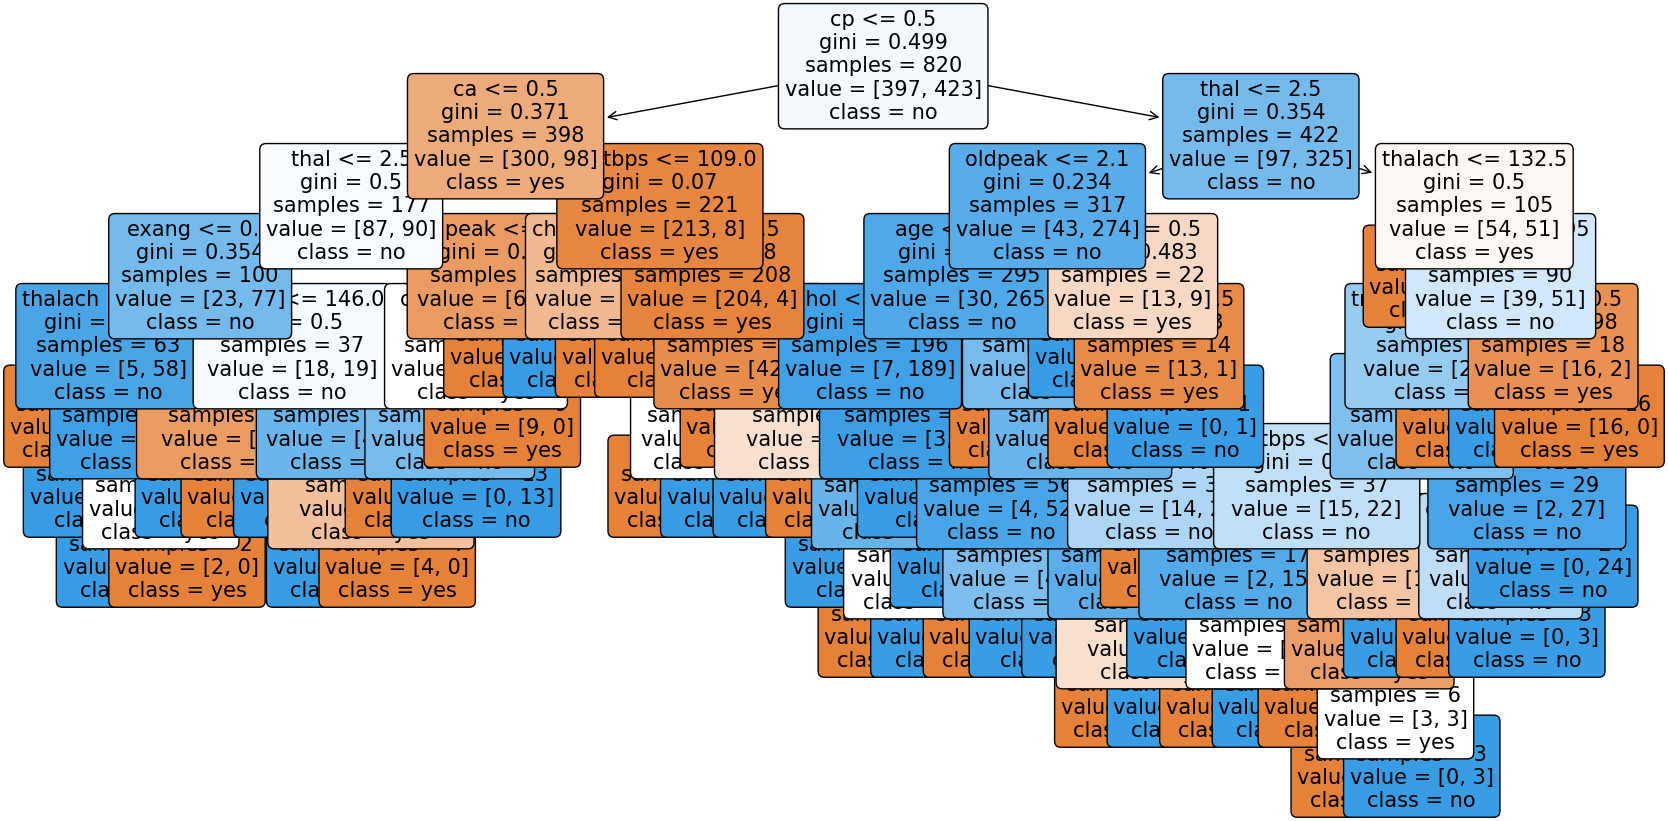

In [31]:
plt.figure(figsize = (20,10))
plot_tree(clf , feature_names= list(x.columns) , class_names=list(label) , rounded=True , filled=True , fontsize=15)
plt.show()